In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import numpy as np
from sklearn.cluster import MeanShift

In [2]:
pd.options.display.max_seq_items = 2000

In [3]:
kinetic_data = pd.read_pickle('kinetic_data_dwsim.pkl')

In [4]:
cols_Fout_exp_gases = [
    'F_CH4_s_mol_s',
       'F_C2H4_s_mol_s', 'F_C2H6_s_mol_s', 'F_C3H8_s_mol_s'
]

In [5]:
cols_Fout_exp_gasolina = [
     'F_C9', 'F_C10',
    'F_Olef_C9', 'F_Olef_C10'
]

In [6]:
cols_Fout_exp_querosene = [
    'F_C11', 'F_C12', 'F_C13', 'F_C14', 'F_C15', 'F_C16',
    'F_Olef_C11', 'F_Olef_C12', 'F_Olef_C13',
       'F_Olef_C14', 'F_Olef_C15', 'F_Olef_C16'
]

In [7]:
cols_Fout_exp_diesel = [
    'F_C17', 'F_C18', 'F_C19', 'F_C20',
     'F_Olef_C17', 'F_Olef_C18'
]

In [8]:
cols_Fout_exp_pesados = [
    'F_C21', 'F_C22', 'F_C23', 'F_C24',
       'F_C25', 'F_C26', 'F_C27', 'F_C28', 'F_C29', 'F_C30'
]

In [9]:
cols_Fout_dwsim = [
    'F_Methane_out_dwsim', 'F_Water_out_dwsim', 'F_Hydrogen_out_dwsim',
       'F_Carbon monoxide_out_dwsim', 'F_Carbon dioxide_out_dwsim',
       'F_gasolina_out_dwsim', 'F_querosene_out_dwsim', 'F_diesel_out_dwsim',
       'F_pesados_out_dwsim'
                  ]

In [10]:
kinetic_data['F_gases_exp'] = kinetic_data[cols_Fout_exp_gases].sum(axis = 'columns')
kinetic_data['F_gasolina_exp'] = kinetic_data[cols_Fout_exp_gasolina].sum(axis = 'columns')
kinetic_data['F_querosene_exp'] = kinetic_data[cols_Fout_exp_querosene].sum(axis = 'columns')
kinetic_data['F_diesel_exp'] = kinetic_data[cols_Fout_exp_diesel].sum(axis = 'columns')
kinetic_data['F_pesados_exp'] = kinetic_data[cols_Fout_exp_pesados].sum(axis = 'columns')

In [11]:
cols_Fout_exp = [
    'F_H2_s_mol_s', 'F_gases_exp', 'F_CO_s_mol_s', 'F_CO2_s_mol_s',
    'F_H2O_s_mol_s',
    'F_gasolina_exp', 'F_querosene_exp', 'F_diesel_exp', 'F_pesados_exp'
          ]

In [12]:
comp_dict_dwsim = {
 'F_Water_out_dwsim': '$\\mathrm{H_2 O}$',
 'F_Hydrogen_out_dwsim': '$\\mathrm{H_2}$',
 'F_Methane_out_dwsim': 'hidrocs. gasosos',
 'F_Carbon monoxide_out_dwsim': '$\\mathrm{CO}$',
 'F_Carbon dioxide_out_dwsim': '$\\mathrm{CO_2}$',
 'F_gasolina_out_dwsim': 'gasolina',
 'F_querosene_out_dwsim': 'querosene',
 'F_diesel_out_dwsim': 'diesel',
 'F_pesados_out_dwsim': 'hidrocs. pesados'
 }

In [13]:
comp_dict_exp = {
    'F_H2_s_mol_s': r'$\mathrm{H_2}$',
    'F_gases_exp': 'hidrocs. gasosos',
    'F_CO_s_mol_s': r'$\mathrm{CO}$',
    'F_CO2_s_mol_s': r'$\mathrm{CO_2}$',
    'F_gasolina_exp': 'gasolina',
    'F_querosene_exp': 'querosene',
    'F_diesel_exp': 'diesel',
    'F_pesados_exp': 'hidrocs. pesados',
    'F_H2O_s_mol_s': '$\\mathrm{H_2 O}$',
}

In [14]:
leg_labels = {'$\\mathrm{H_2}$': '$\\mathrm{H_2}$',
             'hidrocs. gasosos': 'hidrocs. gasosos',
             '$\\mathrm{CO}$': '$\\mathrm{CO}$',
             '$\\mathrm{CO_2}$': '$\\mathrm{CO_2}$',
             '$\\mathrm{H_2 O}$': '$\\mathrm{H_2 O}$',
             'gasolina': 'gasolina',
              'querosene': 'querosene',
              'diesel': 'diesel',
              'hidrocs. pesados': 'hidrocs. pesados',
             }

In [15]:
Fout_exp = kinetic_data[cols_Fout_exp]
Fout_exp['kin_index'] = kinetic_data.index
Fout_exp = Fout_exp.rename(columns=comp_dict_exp) 
Fout_dwsim = kinetic_data[cols_Fout_dwsim]
Fout_dwsim['kin_index'] = kinetic_data.index
Fout_dwsim = Fout_dwsim.rename(columns=comp_dict_dwsim) 

In [16]:
# have to reorder columns
Fout_exp = Fout_exp[Fout_dwsim.columns]

In [17]:
Fout_dwsim = Fout_dwsim.melt(id_vars = ['kin_index'],
                             var_name = 'component',
                             value_name = 'Fout_dwsim')

In [18]:
Fout_exp = Fout_exp.melt(id_vars = ['kin_index'],
                         var_name = 'component',
                         value_name = 'Fout_exp')

In [19]:
plotF = pd.concat((Fout_exp, Fout_dwsim.Fout_dwsim), axis = 'columns')

In [20]:
plotF['legend'] = plotF['component'].map(leg_labels)

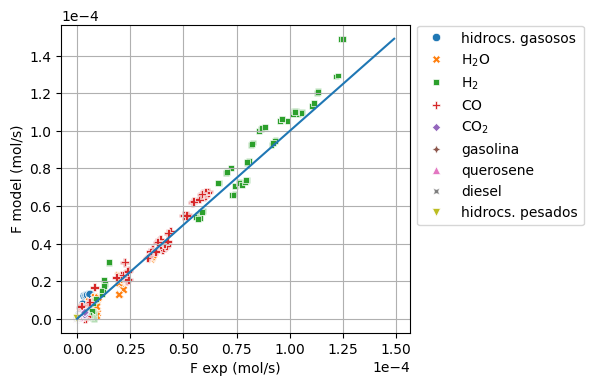

In [21]:
fig, axs = plt.subplots(figsize=(4.5,4))

max_xy = max(plotF.Fout_exp.max(), plotF.Fout_dwsim.max())
min_xy = min(plotF.Fout_exp.min(), plotF.Fout_dwsim.min())

sns.scatterplot(
                data=plotF, 
                x='Fout_exp', 
                y='Fout_dwsim', 
                ax = axs,
                hue = 'legend',
                style = 'legend',
)

axs.plot((0, max_xy), (0, max_xy))
axs.set_xlabel('F exp (mol/s)')
axs.set_ylabel('F model (mol/s)')
axs.grid('both')
axs.ticklabel_format(style='sci', axis='both', scilimits=(0, 0))
plt.legend(bbox_to_anchor=(1.0, 1.02))

In [22]:
molar_mass_dict = {
 '$\\mathrm{H_2}$':           2,
 'hidrocs. gasosos':          26.94,
 '$\\mathrm{CO}$':            12+16,
 '$\\mathrm{CO_2}$':          44,
 '$\\mathrm{H_2 O}$':         18,
    'gasolina': 100.08,
    'querosene': 181.46,
    'diesel': 258.96,
    'hidrocs. pesados': 356.29,
 }

In [23]:
plotF['MM (g/mol)'] = plotF.component.map(molar_mass_dict)

In [24]:
plotF[r'$\dot{m}_{\mathrm{out,exp}}$ (g/d)'] = (
    86400 * plotF['MM (g/mol)'] * plotF['Fout_exp']
)
plotF[r'$\dot{m}_{\mathrm{out,dwsim}}$ (g/d)'] = (
    86400 * plotF['MM (g/mol)'] * plotF['Fout_dwsim']
)

In [25]:
plot_m = plotF.groupby(['kin_index', 'legend']).sum()

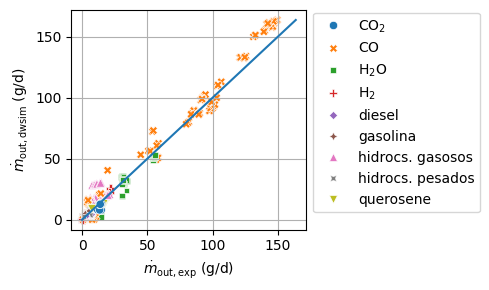

In [26]:
fig, axs = plt.subplots(figsize=(5,3))

max_xy = max(plotF[r'$\dot{m}_{\mathrm{out,exp}}$ (g/d)'].max(), 
             plotF[r'$\dot{m}_{\mathrm{out,dwsim}}$ (g/d)'].max())
scale = 'linear'

sns.scatterplot(
                data=plot_m, 
                x=r'$\dot{m}_{\mathrm{out,exp}}$ (g/d)', 
                y=r'$\dot{m}_{\mathrm{out,dwsim}}$ (g/d)', 
                ax = axs,
                hue = 'legend',
                style = 'legend',
)

axs.plot((0, max_xy), (0, max_xy))
axs.grid('both')
axs.set_xscale(scale)
axs.set_yscale(scale)
plt.legend(bbox_to_anchor=(1.0, 1.02))
plt.tight_layout()
plt.savefig('parity_lumped.pdf')

In [27]:
kinetic_data_lumped = kinetic_data[
    ['P_abs_Pa', 'T_R_K',
       'F_H2_e_mol_s', 'F_CO_e_mol_s',
       'F_H2_s_mol_s', 'F_CO_s_mol_s', 'F_CO2_s_mol_s',
       'F_H2O_s_mol_s',
      'F_gases_exp', 'F_gasolina_exp',
       'F_querosene_exp', 'F_diesel_exp', 'F_pesados_exp']
]

In [28]:
kinetic_data_lumped

,P_abs_Pa,T_R_K,F_H2_e_mol_s,F_CO_e_mol_s,F_H2_s_mol_s,F_CO_s_mol_s,F_CO2_s_mol_s,F_H2O_s_mol_s,F_gases_exp,F_gasolina_exp,F_querosene_exp,F_diesel_exp,F_pesados_exp
45,2247156.184,506.15,0.000093,0.000030,0.000076,2.417917e-05,7.569846e-08,0.000006,1.012954e-06,4.266305e-08,1.609524e-07,6.334809e-08,5.550005e-08
46,2240261.427,506.15,0.000091,0.000030,0.000074,2.333819e-05,7.426536e-08,0.000006,1.160886e-06,4.121362e-08,1.554842e-07,6.119590e-08,5.361449e-08
47,2233366.670,506.15,0.000091,0.000030,0.000074,2.344620e-05,8.512772e-08,0.000006,1.047908e-06,4.206965e-08,1.587137e-07,6.246697e-08,5.472809e-08
48,2233366.670,506.15,0.000093,0.000030,0.000076,2.398895e-05,7.633617e-08,0.000006,1.162960e-06,4.163989e-08,1.570924e-07,6.182884e-08,5.416902e-08
54,2191998.128,495.15,0.000084,0.000048,0.000070,4.267235e-05,2.350200e-08,0.000006,3.395697e-07,4.592042e-08,1.732413e-07,6.818478e-08,5.973754e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...
289,2150629.586,544.15,0.000087,0.000045,0.000005,1.925954e-06,3.539016e-06,0.000036,6.068646e-06,6.522636e-07,1.073368e-06,3.199925e-07,2.150358e-07
302,4163898.630,544.15,0.000055,0.000027,0.000002,4.080492e-07,3.509761e-06,0.000020,8.156088e-06,2.962629e-07,4.910649e-07,1.353963e-07,4.963830e-08
303,4163898.630,544.15,0.000057,0.000028,0.000002,4.344232e-07,3.888250e-06,0.000020,9.079831e-06,2.863078e-07,4.745641e-07,1.308467e-07,4.797035e-08
304,4163898.630,544.15,0.000055,0.000028,0.000002,3.198908e-07,3.628897e-06,0.000020,8.438060e-06,2.931292e-07,4.858707e-07,1.339642e-07,4.911326e-08


In [29]:
rename_lumped = {
    'P_abs_Pa': 'Pressão absoluta (Pa)',
    'T_R_K': 'Temperatura do reator (K)',
    'F_H2_e_mol_s': 'F H2 entra (mol/s)', 
    'F_CO_e_mol_s': 'F CO entra (mol/s)',
    'F_H2_s_mol_s': 'F H2 sai (mol/s)',
    'F_CO_s_mol_s': 'F CO sai (mol/s)', 
    'F_CO2_s_mol_s': 'F CO2 sai (mol/s)',
    'F_H2O_s_mol_s': 'F H2O sai (mol/s)',
    'F_gases_exp': 'F gases sai (mol/s)', 
    'F_gasolina_exp': 'F gasolina sai (mol/s)',
    'F_querosene_exp': 'F querosene sai (mol/s)', 
    'F_diesel_exp': 'F diesel sai (mol/s)', 
    'F_pesados_exp': 'F pesados sai (mol/s)'}

In [30]:
kinetic_data_lumped = kinetic_data_lumped.rename(columns = rename_lumped)

In [31]:
kinetic_data_lumped

,Pressão absoluta (Pa),Temperatura do reator (K),F H2 entra (mol/s),F CO entra (mol/s),F H2 sai (mol/s),F CO sai (mol/s),F CO2 sai (mol/s),F H2O sai (mol/s),F gases sai (mol/s),F gasolina sai (mol/s),F querosene sai (mol/s),F diesel sai (mol/s),F pesados sai (mol/s)
45,2247156.184,506.15,0.000093,0.000030,0.000076,2.417917e-05,7.569846e-08,0.000006,1.012954e-06,4.266305e-08,1.609524e-07,6.334809e-08,5.550005e-08
46,2240261.427,506.15,0.000091,0.000030,0.000074,2.333819e-05,7.426536e-08,0.000006,1.160886e-06,4.121362e-08,1.554842e-07,6.119590e-08,5.361449e-08
47,2233366.670,506.15,0.000091,0.000030,0.000074,2.344620e-05,8.512772e-08,0.000006,1.047908e-06,4.206965e-08,1.587137e-07,6.246697e-08,5.472809e-08
48,2233366.670,506.15,0.000093,0.000030,0.000076,2.398895e-05,7.633617e-08,0.000006,1.162960e-06,4.163989e-08,1.570924e-07,6.182884e-08,5.416902e-08
54,2191998.128,495.15,0.000084,0.000048,0.000070,4.267235e-05,2.350200e-08,0.000006,3.395697e-07,4.592042e-08,1.732413e-07,6.818478e-08,5.973754e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...
289,2150629.586,544.15,0.000087,0.000045,0.000005,1.925954e-06,3.539016e-06,0.000036,6.068646e-06,6.522636e-07,1.073368e-06,3.199925e-07,2.150358e-07
302,4163898.630,544.15,0.000055,0.000027,0.000002,4.080492e-07,3.509761e-06,0.000020,8.156088e-06,2.962629e-07,4.910649e-07,1.353963e-07,4.963830e-08
303,4163898.630,544.15,0.000057,0.000028,0.000002,4.344232e-07,3.888250e-06,0.000020,9.079831e-06,2.863078e-07,4.745641e-07,1.308467e-07,4.797035e-08
304,4163898.630,544.15,0.000055,0.000028,0.000002,3.198908e-07,3.628897e-06,0.000020,8.438060e-06,2.931292e-07,4.858707e-07,1.339642e-07,4.911326e-08


In [32]:
kinetic_data_lumped.to_excel('FTS_kinetic_data_lumped.xlsx', index = False)

In [33]:
kinetic_data_lumped.style.format("{:.2E}").hide(axis="index").to_latex("FTS_kinetic_data_lumped.tex")